Your Task:
Implement the Softmax and Prediction functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

" Do not Modify the Test Case."

1. Starter Code - Softmax Function:

In [1]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
    - m is the number of samples
    - n is the number of classes

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n)
    where each row sums to 1.
    """

    # Numerical stabilization (subtract max of each row)
    z_stable = z - np.max(z, axis=1, keepdims=True)

    # Exponentiate
    exp_z = np.exp(z_stable)

    # Normalize
    softmax_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return softmax_probs


# ---------------- Test Case (Do Not Modify) ----------------

# Example test case
z_test = np.array([[2.0, 1.0, 0.1],
                   [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

# Verify if the sum of probabilities for each row is 1 using assert
row_sums = np.sum(softmax_output, axis=1)

# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")

Softmax function passed the test case!


Starter Code - Prediction Function:

In [2]:
import numpy as np

def softmax(z):
    # Numerical stabilization
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    numpy.ndarray: Predicted class labels of shape (n,)
    """

    # Compute logits
    z = np.dot(X, W) + b

    # Apply softmax to get probabilities
    probs = softmax(z)

    # Select class with highest probability
    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes


# ---------------- Prediction Test Case ----------------

# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])  # Feature matrix (3 samples, 2 features)
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])    # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3])                       # Bias (3 classes)

# Expected Output:
# The function should return an array with class labels (0, 1, or 2)
y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

# Print the predicted labels
print("Predicted class labels:", y_pred_test)


Predicted class labels: [1 1 0]


Your Task:
Implement the Loss and Cost functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

" Do not Modify the Test Case."

1. Implementation of Loss Function:

In [3]:
import numpy as np

def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.

    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities (n, c)
    y (numpy.ndarray): True one-hot labels (n, c)

    Returns:
    float: Cross-entropy loss
    """

    # Small constant for numerical stability
    epsilon = 1e-15

    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Cross-entropy loss
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]

    return loss


# ---------------- Test Case (Do Not Modify) ----------------

# Define correct predictions (low loss scenario)
y_true_correct = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

y_pred_correct = np.array([
    [0.9, 0.05, 0.05],
    [0.1, 0.85, 0.05],
    [0.05, 0.1, 0.85]
])

# Define incorrect predictions (high loss scenario)
y_pred_incorrect = np.array([
    [0.05, 0.05, 0.9],
    [0.1, 0.05, 0.85],
    [0.85, 0.1, 0.05]
])

# Compute loss for both cases
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Validate that incorrect predictions lead to a higher loss
assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

# Print results
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


2. Implementation of Cost Function:

In [ ]:
import numpy as np

def softmax(z):
    # Numerical stabilization
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    """

    n = X.shape[0]

    # Step 1: Compute logits
    z = np.dot(X, W) + b

    # Step 2: Compute probabilities
    y_pred = softmax(z)

    # Step 3: Avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Step 4: Compute total cross-entropy loss
    total_loss = -np.sum(y * np.log(y_pred))

    # Return average loss
    return total_loss / n


# ---------------- Test Case (Do Not Modify) ----------------

# Example 1: Correct Prediction (Closer predictions)
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

# Example 2: Incorrect Prediction (Far off predictions)
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

# Compute cost for correct predictions
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)

# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Check if the cost for incorrect predictions is greater than for correct predictions
assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"

# Print the costs for verification
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

3.3.1 Your Task:
Implement the Compute Gradients and Gradient Descent functions using either of the following
approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

" Do not Modify the Test Case."

Implementation of Compute Gradients:

In [4]:
import numpy as np

def softmax(z):
    # Numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    tuple: Gradients with respect to weights (d, c) and biases (c,)
    """

    n = X.shape[0]

    # Compute logits
    z = np.dot(X, W) + b

    # Compute predicted probabilities
    y_pred = softmax(z)

    # Gradient with respect to weights
    grad_W = np.dot(X.T, (y_pred - y)) / n

    # Gradient with respect to biases
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


# ---------------- Test Case (Do Not Modify) ----------------

# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8],
                   [0.5, 0.5],
                   [0.9, 0.1]])

y_test = np.array([[1, 0, 0],
                   [0, 1, 0],
                   [0, 0, 1]])

# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])

b_test = np.array([0.1, 0.2, 0.3])

# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manually compute the predicted probabilities
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

# Compute the manually computed gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

# Assert correctness
assert np.allclose(grad_W, grad_W_manual), f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"

# Print results
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


Implementations of Gradient Descent Algorithm:

In [5]:
import numpy as np

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n


def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    """

    cost_history = []

    for i in range(n_iter):

        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Compute cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Optionally print cost
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return W, b, cost_history


1. Starter - Code - load and prepare mnist:

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def plot_sample_images(X, y):
    """
    Plot one sample image for each digit class (0–9).
    """
    plt.figure(figsize=(10, 4))

    for digit in range(10):
        index = np.where(y == digit)[0][0]  # first occurrence of the digit
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, digit + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.

    Arguments:
    csv_file (str): Path to the CSV file containing MNIST data
    test_size (float): Proportion of data used as test set
    random_state (int): Random seed

    Returns:
    X_train, X_test, y_train, y_test
    """

    # Load dataset
    df = pd.read_csv(csv_file)

    # Separate labels and features
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    # Normalize pixel values
    X = X / 255.0

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Plot sample images
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

2. Starter - Code - plot sample images:

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """

    plt.figure(figsize=(10, 4))

    unique_classes = np.unique(y)  # Get unique class labels

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # Find first occurrence of the class
        image = X[index].reshape(28, 28)    # Reshape 1D array to 28x28

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

3.5 Training of the Model: No idea

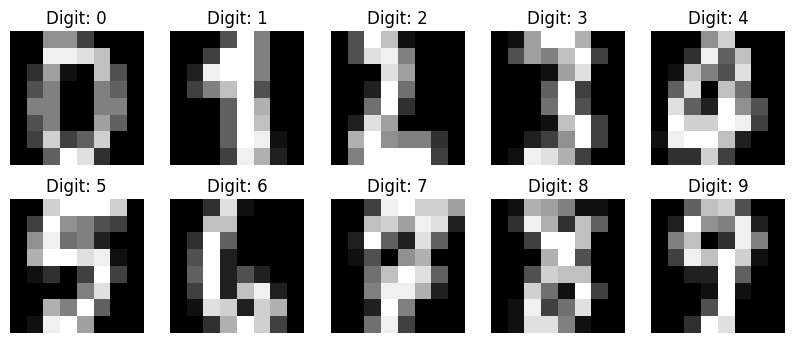

Digits dataset ready! X_train shape: (1437, 64)


In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt

# Load digits dataset
digits = load_digits()
X = digits.data / 16.0  # normalize pixel values (0-16 -> 0-1)
y = digits.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot one sample per class
plt.figure(figsize=(10,4))
for digit in range(10):
    idx = np.where(y_train==digit)[0][0]
    plt.subplot(2,5,digit+1)
    plt.imshow(X_train[idx].reshape(8,8), cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')
plt.show()

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

print("Digits dataset ready! X_train shape:", X_train.shape)

3.6 Evaluating Your Model Performance:

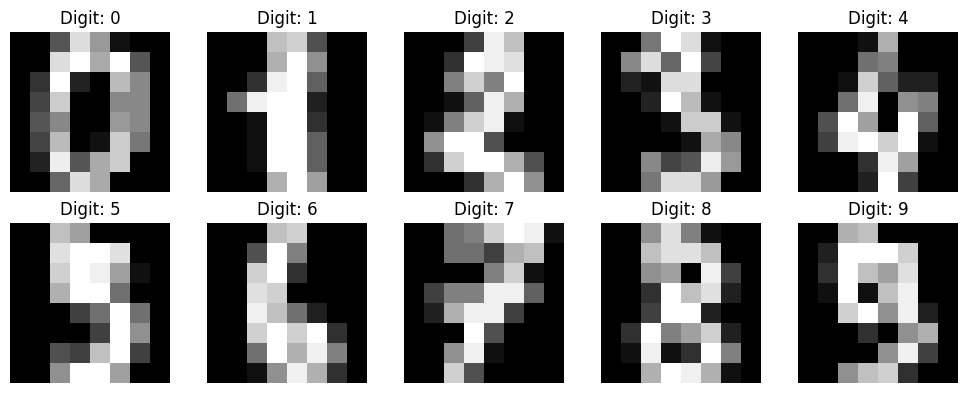

Iteration 0: Cost = 2.2782
Iteration 100: Cost = 1.1159
Iteration 200: Cost = 0.7329
Iteration 300: Cost = 0.5648
Iteration 400: Cost = 0.4715
Iteration 500: Cost = 0.4118
Iteration 600: Cost = 0.3698
Iteration 700: Cost = 0.3385
Iteration 800: Cost = 0.3140
Iteration 900: Cost = 0.2942


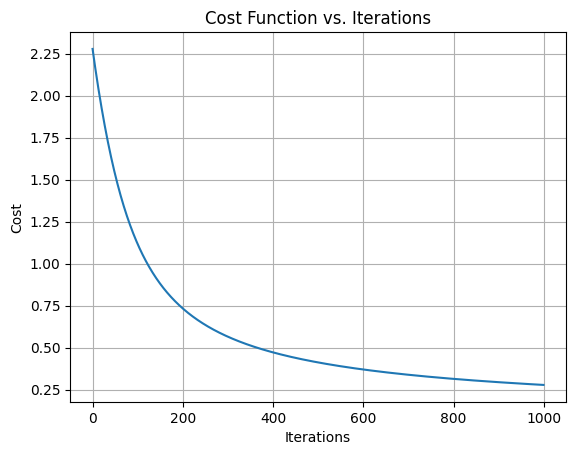


Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 25  1  0  0  0  0  0  0  2]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 32  0  0  0  0  2  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 42  1  0  0  4]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  1  0  0  0  1  0  1  1 36]]
Precision: 0.95
Recall: 0.94
F1-Score: 0.94


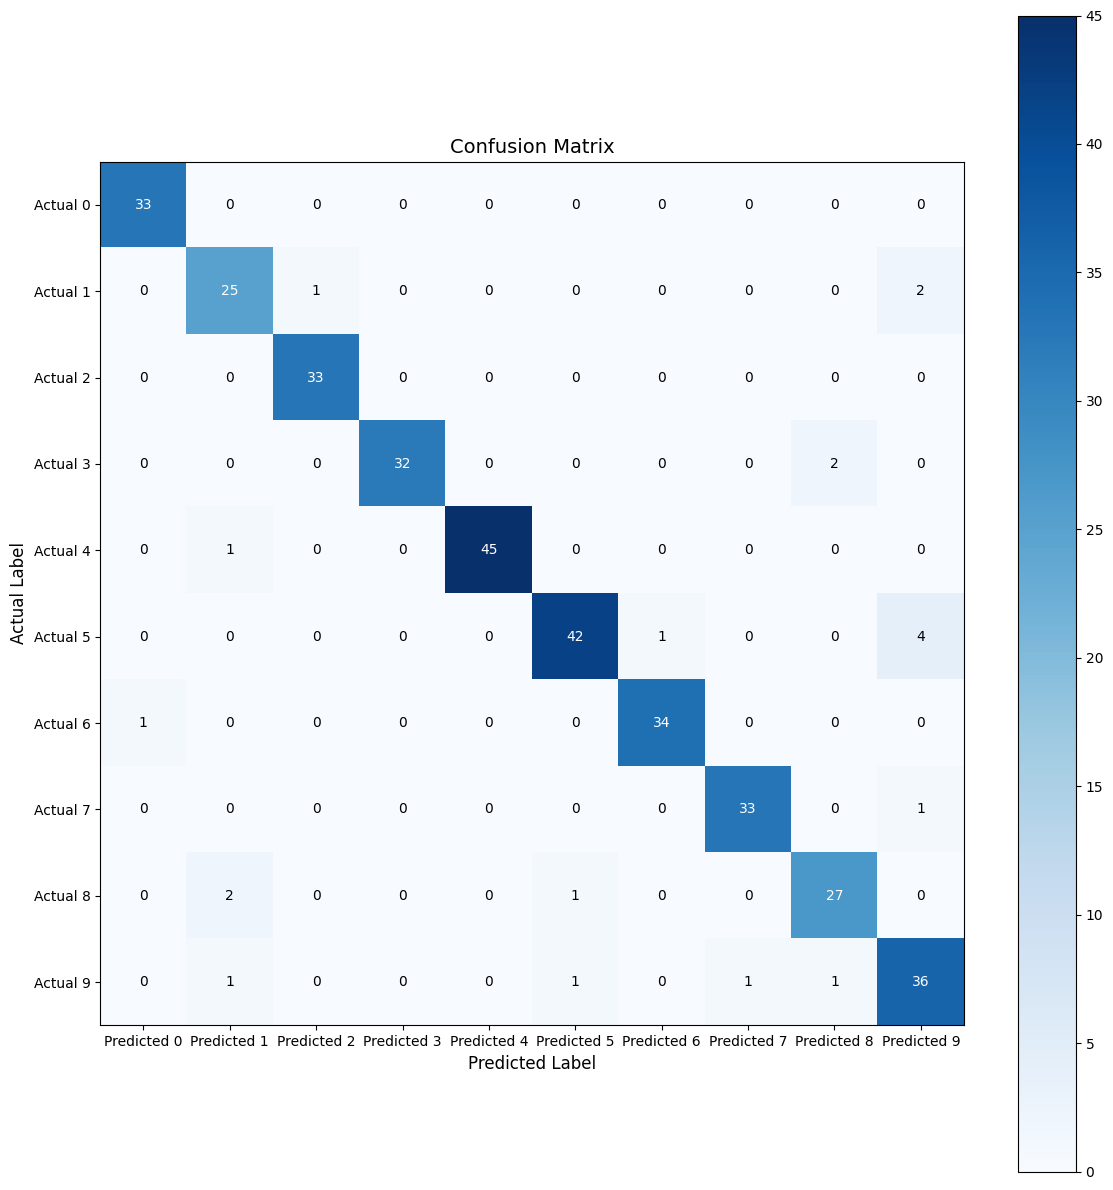

Test Accuracy: 94.44%


In [9]:
# ------------------ Imports ------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# ------------------ Helper Functions ------------------

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1-epsilon)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    return W, b, cost_history

def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)

def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

def plot_sample_images(X, y):
    plt.figure(figsize=(10,4))
    for digit in np.unique(y):
        idx = np.where(y == digit)[0][0]
        plt.subplot(2,5,digit+1)
        plt.imshow(X[idx].reshape(8,8), cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ------------------ Load Dataset ------------------
digits = load_digits()
X = digits.data / 16.0  # normalize pixel values (0-16 → 0-1)
y = digits.target

# Plot one sample per class
plot_sample_images(X, y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------ One-hot Encode Labels ------------------
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1,1))
y_test_onehot = encoder.transform(y_test.reshape(-1,1))

# ------------------ Initialize Parameters ------------------
d = X_train.shape[1]  # number of features
c = y_train_onehot.shape[1]  # number of classes
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# ------------------ Train Softmax Regression ------------------
alpha = 0.1
n_iter = 1000
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train_onehot, W, b, alpha, n_iter, show_cost=True)

# ------------------ Plot Loss ------------------
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# ------------------ Evaluate Model ------------------
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
cm, precision, recall, f1 = evaluate_classification(y_test, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# ------------------ Visualize Confusion Matrix ------------------
fig, ax = plt.subplots(figsize=(12,12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > np.max(cm)/2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

# ------------------ Test Accuracy ------------------
accuracy = np.mean(y_pred_test == y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

4 Exercise - Linear Separability and Logistic Regression.

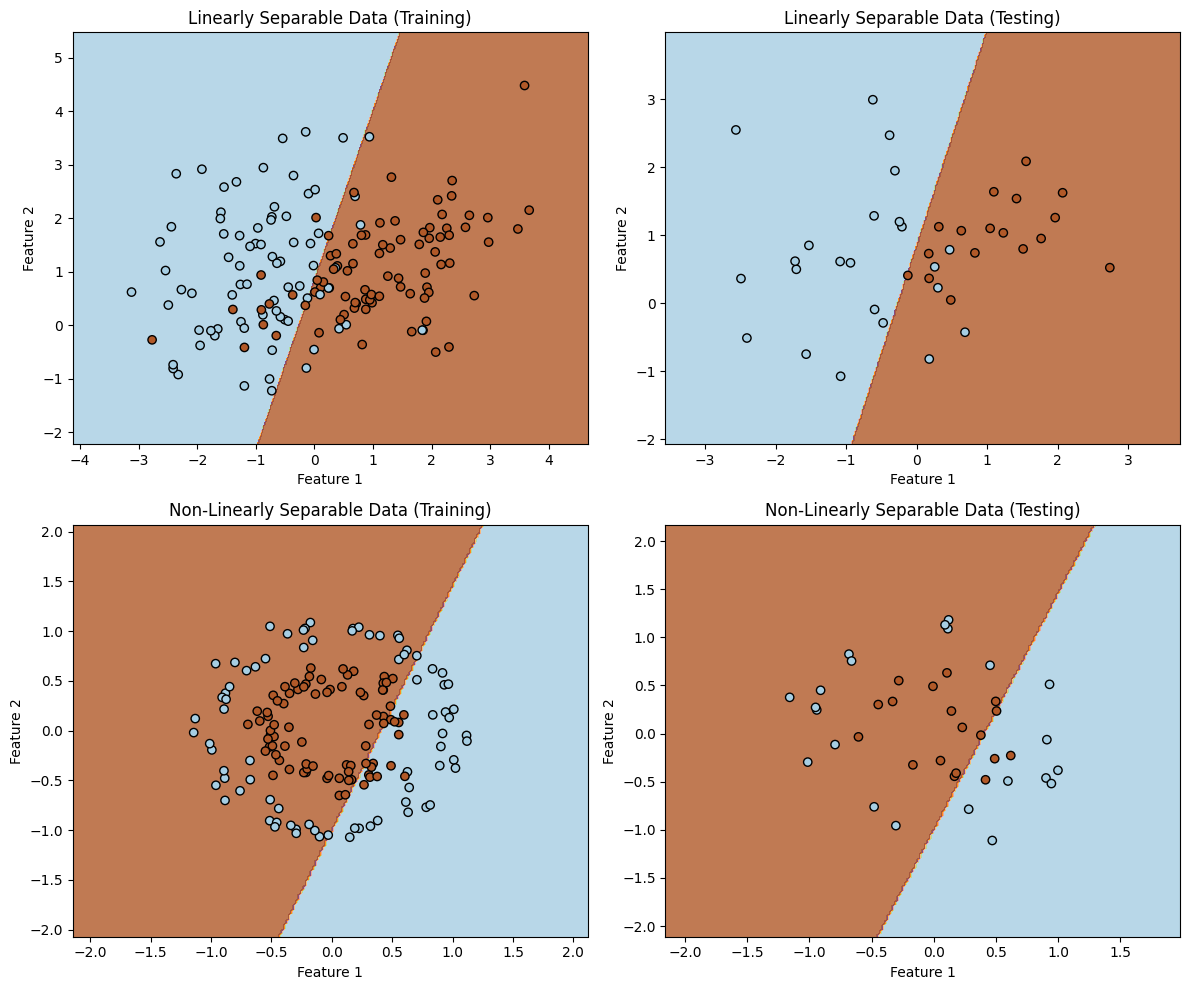

In [10]:
# ------------------ Imports ------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# ------------------ Set random seed ------------------
np.random.seed(42)

# ------------------ Linearly Separable Dataset ------------------
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# ------------------ Non-Linearly Separable Dataset (Circles) ------------------
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# ------------------ Decision Boundary Plot Function ------------------
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# ------------------ Plotting ------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Linearly separable data (Training)
plot_decision_boundary(
    axes[0, 0], logistic_model_linear_separable, X_train_linear, y_train_linear,
    'Linearly Separable Data (Training)'
)

# Linearly separable data (Testing)
plot_decision_boundary(
    axes[0, 1], logistic_model_linear_separable, X_test_linear, y_test_linear,
    'Linearly Separable Data (Testing)'
)

# Non-linearly separable data (Training)
plot_decision_boundary(
    axes[1, 0], logistic_model_non_linear_separable, X_train_non_linear, y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

# Non-linearly separable data (Testing)
plot_decision_boundary(
    axes[1, 1], logistic_model_non_linear_separable, X_test_non_linear, y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()